# Ablation: Loss Unification (BCE+Dice for Method1 & Method2)

## Purpose

現在の5手法ではLoss関数が異なるため、手法間比較の公平性に課題がある：

| Method | 現在のLoss | 備考 |
|--------|-----------|------|
| Method1 | Eyelid: BCE+Dice, Ellipse: MSE+BCE | Diceなし(楕円部分) |
| Method2 | Weighted BCE (pos_weight=3.0) | Diceなし |
| Method3 | Multi-class Dice only | CEなし |
| Method4 | CE + Dice | ベースライン |
| Method5 | BCE + Dice (per-channel) | チャネル重み付き |

本実験では Method1 と Method2 のLossに **Dice損失を追加** し、BCE+Dice構造に統一する。
これにより Method4/5 との比較における「Loss由来」vs「アーキテクチャ由来」の性能差を切り分ける。

### 変更内容

- **Method1**: 楕円部分の `BCE` → `BCE + Dice`（render_ellipse_logitsによる微分可能レンダリング）
- **Method2**: エッジ部分の `Weighted BCE` → `Weighted BCE + Dice`

### 実験設定

- 5-fold CV, 300 epochs, early stopping (patience=30)
- VGG16-BN encoder + U-Net decoder（crossvalidation.ipynbと同一）
- 評価: Dice (Eyelid/Iris/Pupil/Mean)

In [2]:
import os
import json
import random
import time
import gc
from pathlib import Path
from datetime import datetime

import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm
from skimage.measure import EllipseModel
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

Device: cuda
GPU: NVIDIA GeForce RTX 3080 Ti Laptop GPU


In [3]:
# ===== Configuration =====
IMAGE_HEIGHT = 512
IMAGE_WIDTH = 512
NUM_EPOCHS = 300
BATCH_SIZE = 8
LR = 1e-4
PATIENCE = 30
NUM_WORKERS = 0  # Windows
NUM_FOLDS = 5

# Paths
IMAGE_DIR = Path('Images/images')
LABEL_SEG_DIR = Path('Images/labels_seg')
LABEL_OBB_DIR = Path('Images/labels_obb')
FOLD_INDICES_PATH = Path('fold_indices.json')
ELLIPSE_CACHE_PATH = Path('cache/ellipse_params.npz')

# Output
MODEL_DIR = Path('model/ablation_loss_unification')
RESULT_DIR = Path('results')
CACHE_DIR = Path('cache')
PROGRESS_FILE = CACHE_DIR / 'ablation_loss_unification_progress.json'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Methods to train
TRAIN_METHODS = [1, 2]  # Method1, Method2 with unified loss

print(f'Epochs: {NUM_EPOCHS}, Batch: {BATCH_SIZE}, LR: {LR}, Patience: {PATIENCE}')
print(f'Methods to train: {TRAIN_METHODS}')

Epochs: 300, Batch: 8, LR: 0.0001, Patience: 30
Methods to train: [1, 2]


In [4]:
# ===== Load fold indices =====
with open(FOLD_INDICES_PATH, 'r') as f:
    fold_data = json.load(f)

all_image_paths = sorted(IMAGE_DIR.glob('*.jpg')) + sorted(IMAGE_DIR.glob('*.png'))
print(f'Total images: {len(all_image_paths)}')
print(f'Folds: {len(fold_data)}')

# Load ellipse cache for Method1
def load_ellipse_cache():
    if ELLIPSE_CACHE_PATH.exists():
        return np.load(str(ELLIPSE_CACHE_PATH), allow_pickle=True)
    return None

ellipse_cache = load_ellipse_cache()
if ellipse_cache is not None:
    print(f'Ellipse cache loaded: {len(ellipse_cache.files)} entries')
else:
    print('WARNING: Ellipse cache not found. Run crossvalidation.ipynb cell 4 first.')

Total images: 4467
Folds: 5


In [5]:
# ===== Dataset =====

def _resize_mask(m):
    if m is None:
        return np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), dtype=np.uint8)
    return cv2.resize(m, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_NEAREST)

class EyeSegmentationDataset(Dataset):
    def __init__(self, image_paths, label_seg_dir, label_obb_dir, 
                 use_ellipse_cache=True):
        self.image_paths = image_paths
        self.label_seg_dir = Path(label_seg_dir)
        self.label_obb_dir = Path(label_obb_dir)
        self.ellipse_cache = load_ellipse_cache() if use_ellipse_cache else None

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        p = self.image_paths[idx]
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_LINEAR)

        stem = p.stem
        mask_lid   = cv2.imread(str(self.label_seg_dir / f"{stem}_mask_lid.png"), 0)
        mask_iris  = cv2.imread(str(self.label_obb_dir / f"{stem}_mask_iris.png"), 0)
        mask_pupil = cv2.imread(str(self.label_obb_dir / f"{stem}_mask_pupil.png"), 0)

        mask_lid   = _resize_mask(mask_lid)
        mask_iris  = _resize_mask(mask_iris)
        mask_pupil = _resize_mask(mask_pupil)

        # to tensor
        img_t = torch.from_numpy(img).float().permute(2,0,1) / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
        std  = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
        img_t = (img_t - mean) / std

        d = dict(
            image      = img_t,
            mask_lid   = torch.from_numpy(mask_lid).long(),
            mask_iris  = torch.from_numpy(mask_iris).long(),
            mask_pupil = torch.from_numpy(mask_pupil).long(),
            filename   = p.name
        )

        # Ellipse parameters for Method1
        if self.ellipse_cache is not None:
            iris_key = f"{stem}_iris"
            pupil_key = f"{stem}_pupil"
            if iris_key in self.ellipse_cache.files and pupil_key in self.ellipse_cache.files:
                d['ellipse_iris'] = torch.from_numpy(self.ellipse_cache[iris_key]).float()
                d['ellipse_pupil'] = torch.from_numpy(self.ellipse_cache[pupil_key]).float()
            else:
                d['ellipse_iris'] = torch.zeros(5, dtype=torch.float32)
                d['ellipse_pupil'] = torch.zeros(5, dtype=torch.float32)

        return d

print('Dataset class defined.')

Dataset class defined.


In [6]:
# ===== Model Architecture (same as crossvalidation.ipynb) =====

class UNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = torchvision.models.vgg16_bn(weights='DEFAULT')
        self.features = vgg.features

    def forward(self, x):
        feats = {}
        for i, layer in enumerate(self.features):
            x = layer(x)
            if i == 5:  feats['0'] = x
            if i == 12: feats['1'] = x
            if i == 22: feats['2'] = x
            if i == 32: feats['3'] = x
        feats['4'] = x
        return feats

class UNetDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.dec4 = self._blk(512+512, 256)
        self.dec3 = self._blk(256+256, 128)
        self.dec2 = self._blk(128+128, 64)
        self.dec1 = self._blk(64+64,   64)

    def _blk(self, c_in, c_out):
        return nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
            nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU()
        )

    def forward(self, f):
        x = f['4']
        x = F.interpolate(x, size=f['3'].shape[-2:], mode='bilinear', align_corners=False)
        x = self.dec4(torch.cat([x, f['3']], 1))
        x = F.interpolate(x, size=f['2'].shape[-2:], mode='bilinear', align_corners=False)
        x = self.dec3(torch.cat([x, f['2']], 1))
        x = F.interpolate(x, size=f['1'].shape[-2:], mode='bilinear', align_corners=False)
        x = self.dec2(torch.cat([x, f['1']], 1))
        x = F.interpolate(x, size=f['0'].shape[-2:], mode='bilinear', align_corners=False)
        x = self.dec1(torch.cat([x, f['0']], 1))
        x = F.interpolate(x, size=(IMAGE_HEIGHT, IMAGE_WIDTH), mode='bilinear', align_corners=False)
        return x

class UNetMethod1(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = UNetEncoder()
        self.decoder = UNetDecoder()
        self.head_lid = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 1, 1)
        )
        self.head_iris = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(64, 5)
        )
        self.head_pupil = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(64, 5)
        )

    def forward(self, x):
        f = self.encoder(x)
        d = self.decoder(f)
        return dict(
            eyelid_seg    = self.head_lid(d),
            iris_ellipse  = self.head_iris(d),
            pupil_ellipse = self.head_pupil(d)
        )

class UNetMethod2(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = UNetEncoder()
        self.decoder = UNetDecoder()
        self.head_edge = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 3, 1)
        )

    def forward(self, x):
        f = self.encoder(x)
        d = self.decoder(f)
        return dict(edge_logits=self.head_edge(d))

print('Model classes defined.')

Model classes defined.


In [7]:
# ===== Helper functions =====

def dice_loss(pred: torch.Tensor, tgt: torch.Tensor, smooth: float = 1e-5) -> torch.Tensor:
    """Binary Dice Loss: 1 - Dice coefficient"""
    pred_f = pred.reshape(-1)
    tgt_f  = tgt.reshape(-1)
    inter  = (pred_f * tgt_f).sum()
    union  = pred_f.sum() + tgt_f.sum()
    return 1.0 - (2 * inter + smooth) / (union + smooth)

def render_ellipse_logits(params: torch.Tensor, H: int, W: int, device, scale: float = 10.0) -> torch.Tensor:
    """Differentiable ellipse rendering: params(B,5) -> logits(B,H,W)"""
    B = params.shape[0]
    cx = params[:,0].clamp(0,1) * W
    cy = params[:,1].clamp(0,1) * H
    a  = (params[:,2].clamp(1e-6,1)*W)/2.0
    b  = (params[:,3].clamp(1e-6,1)*H)/2.0
    theta = params[:,4]*2.0*np.pi - np.pi

    ys, xs = torch.meshgrid(
        torch.arange(H, device=device, dtype=torch.float32),
        torch.arange(W, device=device, dtype=torch.float32),
        indexing='ij'
    )
    xs = xs.unsqueeze(0).expand(B,-1,-1)
    ys = ys.unsqueeze(0).expand(B,-1,-1)

    dx = xs - cx.view(B,1,1)
    dy = ys - cy.view(B,1,1)

    cos_t = torch.cos(theta).view(B,1,1)
    sin_t = torch.sin(theta).view(B,1,1)
    dx_r =  dx * cos_t + dy * sin_t
    dy_r = -dx * sin_t + dy * cos_t

    ellipse_eq = (dx_r / (a.view(B,1,1)+1e-6))**2 + (dy_r / (b.view(B,1,1)+1e-6))**2
    return scale * (1.0 - ellipse_eq)

def mask_to_edge(mask_bin: np.ndarray, thickness: int = 3) -> np.ndarray:
    """Mask -> Edge (contour)"""
    m = (mask_bin > 0).astype(np.uint8)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    edge = np.zeros_like(m)
    cv2.drawContours(edge, contours, -1, 1, thickness)
    return edge.astype(np.float32)

def build_method2_targets(batch_masks):
    """Build 3-channel edge targets (B,3,H,W)"""
    lids   = batch_masks['mask_lid'].cpu().numpy()
    irises = batch_masks['mask_iris'].cpu().numpy()
    pupils = batch_masks['mask_pupil'].cpu().numpy()
    B, H, W = lids.shape
    tgt = np.zeros((B, 3, H, W), dtype=np.float32)
    for i in range(B):
        tgt[i, 0] = mask_to_edge(lids[i], thickness=3)
        tgt[i, 1] = mask_to_edge(irises[i], thickness=3)
        tgt[i, 2] = mask_to_edge(pupils[i], thickness=3)
    return torch.from_numpy(tgt)

def dice_binary_np(pred_bin_255, gt_bin_255, smooth=1e-6):
    p = (pred_bin_255 > 0).astype(np.uint8)
    g = (gt_bin_255 > 0).astype(np.uint8)
    inter = (p & g).sum()
    union = p.sum() + g.sum()
    return (2 * inter + smooth) / (union + smooth)

def ellipse_params_to_mask(params, H, W):
    """Ellipse params (5,) -> binary mask (H,W) 0/255"""
    cx = params[0]*W
    cy = params[1]*H
    w  = params[2]*W
    h  = params[3]*H
    angle = params[4]*180.0
    mask = np.zeros((H,W), dtype=np.uint8)
    center = (int(cx), int(cy))
    axes   = (max(1,int(w/2)), max(1,int(h/2)))
    cv2.ellipse(mask, center, axes, angle, 0, 360, 255, thickness=-1)
    return mask

print('Helper functions defined.')

Helper functions defined.


In [8]:
# ===== Unified Loss Functions (BCE + Dice) =====

class LossFunction1_Unified(nn.Module):
    """Method1 Unified: BCE+Dice for all components.
    
    Changes from original LossFunction1:
    - Eyelid: BCE+Dice (unchanged)
    - Ellipse (iris/pupil): MSE(params) + BCE+Dice(rendered mask)
      Original had only BCE(rendered mask), now adds Dice(rendered mask)
    """
    def __init__(self, lambda_ellipse=1.0, lambda_param=0.5, use_param_loss=True):
        super().__init__()
        self.bce_logits = nn.BCEWithLogitsLoss()
        self.lambda_ellipse = float(lambda_ellipse)
        self.lambda_param = float(lambda_param)
        self.use_param_loss = use_param_loss

    def forward(self, pred, target):
        eyelid_logits = pred['eyelid_seg']
        gt_lid = (target['mask_lid'].float() / 255.0)
        H, W = gt_lid.shape[-2:]
        if eyelid_logits.shape[-2:] != (H, W):
            eyelid_logits = F.interpolate(eyelid_logits, size=(H,W), mode='bilinear', align_corners=False)
        eyelid_logits = eyelid_logits.squeeze(1)

        # Eyelid: BCE + Dice (same as original)
        loss_lid = self.bce_logits(eyelid_logits, gt_lid) + dice_loss(torch.sigmoid(eyelid_logits), gt_lid)

        # Ellipse parameters
        iris_params_pred  = torch.sigmoid(pred['iris_ellipse'])
        pupil_params_pred = torch.sigmoid(pred['pupil_ellipse'])

        loss_ellipse = 0.0

        if 'ellipse_iris' in target and 'ellipse_pupil' in target and self.use_param_loss:
            gt_iris_params = target['ellipse_iris']
            gt_pupil_params = target['ellipse_pupil']

            # L2 loss (parameter space)
            loss_param = F.mse_loss(iris_params_pred, gt_iris_params) + \
                         F.mse_loss(pupil_params_pred, gt_pupil_params)
            loss_ellipse += self.lambda_param * loss_param

            # Render GT masks
            gt_iris_logits = render_ellipse_logits(gt_iris_params, H, W, gt_lid.device)
            gt_pupil_logits = render_ellipse_logits(gt_pupil_params, H, W, gt_lid.device)
            gt_iris_mask = torch.sigmoid(gt_iris_logits)
            gt_pupil_mask = torch.sigmoid(gt_pupil_logits)

            # Render predicted masks
            pred_iris_logits = render_ellipse_logits(iris_params_pred, H, W, gt_lid.device)
            pred_pupil_logits = render_ellipse_logits(pupil_params_pred, H, W, gt_lid.device)

            # BCE + Dice on rendered masks (NEW: added Dice)
            loss_mask = self.bce_logits(pred_iris_logits, gt_iris_mask) + \
                        self.bce_logits(pred_pupil_logits, gt_pupil_mask) + \
                        dice_loss(torch.sigmoid(pred_iris_logits), gt_iris_mask) + \
                        dice_loss(torch.sigmoid(pred_pupil_logits), gt_pupil_mask)
            loss_ellipse += loss_mask

        else:
            # Fallback: compare with GT masks directly
            gt_iris  = (target['mask_iris'].float() / 255.0)
            gt_pupil = (target['mask_pupil'].float() / 255.0)
            iris_logits  = render_ellipse_logits(iris_params_pred, H, W, gt_lid.device)
            pupil_logits = render_ellipse_logits(pupil_params_pred, H, W, gt_lid.device)

            # BCE + Dice (NEW: added Dice)
            loss_ellipse = self.bce_logits(iris_logits, gt_iris) + \
                          self.bce_logits(pupil_logits, gt_pupil) + \
                          dice_loss(torch.sigmoid(iris_logits), gt_iris) + \
                          dice_loss(torch.sigmoid(pupil_logits), gt_pupil)

        return loss_lid + self.lambda_ellipse * loss_ellipse


class LossFunction2_Unified(nn.Module):
    """Method2 Unified: Weighted BCE + Dice for edges.
    
    Changes from original LossFunction2:
    - Original: Weighted BCE only
    - New: Weighted BCE + Dice (per-channel)
    """
    def __init__(self, pos_weight: float = 3.0):
        super().__init__()
        self.pos_weight = pos_weight

    def forward(self, pred, target):
        logits = pred['edge_logits']  # (B,3,H,W)
        edge_tgt = build_method2_targets({k: v for k, v in target.items() if 'mask_' in k}).to(logits.device)

        if logits.shape[-2:] != edge_tgt.shape[-2:]:
            logits = F.interpolate(logits, size=edge_tgt.shape[-2:], mode='bilinear', align_corners=False)

        # Weighted BCE (same as original)
        bce_loss_val = F.binary_cross_entropy_with_logits(logits, edge_tgt, reduction='none')
        weight = torch.ones_like(edge_tgt) + (self.pos_weight - 1.0) * edge_tgt
        weighted_bce = (bce_loss_val * weight).mean()

        # Dice loss per channel (NEW)
        prob = torch.sigmoid(logits)
        dice_total = 0.0
        for c in range(3):
            dice_total = dice_total + dice_loss(prob[:, c], edge_tgt[:, c])
        dice_total = dice_total / 3.0

        return weighted_bce + dice_total


print('Unified loss functions defined.')
print()
print('LossFunction1_Unified: BCE+Dice(eyelid) + MSE(params) + BCE+Dice(rendered mask)')
print('LossFunction2_Unified: Weighted BCE + Dice (per-channel edges)')

Unified loss functions defined.

LossFunction1_Unified: BCE+Dice(eyelid) + MSE(params) + BCE+Dice(rendered mask)
LossFunction2_Unified: Weighted BCE + Dice (per-channel edges)


In [9]:
# ===== Training functions =====

def train_epoch(model, loader, criterion, optimizer, scaler, device, show_progress=True):
    model.train()
    total_loss = 0.0
    iterator = tqdm(loader, desc="Train", leave=False) if show_progress else loader
    for batch in iterator:
        image = batch['image'].to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast('cuda'):
            out = model(image)
            target = {k: v.to(device) for k, v in batch.items()
                      if k.startswith('mask_') or k.startswith('ellipse_')}
            loss = criterion(out, target)
        if not torch.isfinite(loss):
            if show_progress: iterator.write("⚠️ Non-finite loss skip")
            continue
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        if show_progress:
            iterator.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / max(1, len(loader))

@torch.no_grad()
def validate_epoch(model, loader, criterion, device, show_progress=True):
    model.eval()
    total_loss = 0.0
    iterator = tqdm(loader, desc="Valid", leave=False) if show_progress else loader
    for batch in iterator:
        image = batch['image'].to(device)
        with autocast('cuda'):
            out = model(image)
            target = {k: v.to(device) for k, v in batch.items()
                      if k.startswith('mask_') or k.startswith('ellipse_')}
            loss = criterion(out, target)
        total_loss += loss.item()
        if show_progress:
            iterator.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / max(1, len(loader))

def run_train_fold(model, loader_tr, loader_va, criterion, optimizer, scaler,
                   device, method_id, fold_idx, save_path,
                   num_epochs=NUM_EPOCHS, patience=PATIENCE, show_progress=True,
                   progress=None):
    best = float('inf')
    wait = 0
    stopped_reason = 'completed'

    for ep in range(1, num_epochs + 1):
        tr_loss = train_epoch(model, loader_tr, criterion, optimizer, scaler, device, show_progress=show_progress)
        va_loss = validate_epoch(model, loader_va, criterion, device, show_progress=show_progress)

        print(f"[M{method_id}-F{fold_idx}] Epoch {ep:03d}/{num_epochs} | Train {tr_loss:.4f} | Val {va_loss:.4f} | "
              f"Best {best:.4f} | Wait {wait}/{patience}")

        if va_loss < best:
            best = va_loss
            wait = 0
            torch.save({
                'epoch': ep,
                'model_state_dict': model.state_dict(),
                'val_loss': best,
            }, save_path)
            if progress is not None:
                update_progress_best(progress, method_id, fold_idx, best, ep)
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {ep}")
                stopped_reason = 'early_stop'
                break

    return best, stopped_reason

print('Training functions defined.')

Training functions defined.


In [10]:
# ===== Evaluation functions =====

def evaluate_method1(model, val_loader, device):
    """Method1: Eyelid + Ellipse params -> Dice"""
    model.eval()
    lid_scores, iris_scores, pupil_scores = [], [], []
    per_rows = []

    for batch in tqdm(val_loader, desc="M1評価", leave=False):
        img = batch['image'].to(device)
        gt_lid   = batch['mask_lid'].cpu().numpy()
        gt_iris  = batch['mask_iris'].cpu().numpy()
        gt_pupil = batch['mask_pupil'].cpu().numpy()
        filenames = batch.get('filename', None)

        with autocast('cuda'):
            out = model(img)

        for b in range(img.shape[0]):
            filename = filenames[b] if filenames else str(b)
            subject_id = str(filename).split('-', 1)[0]

            lid_logits = out['eyelid_seg'][b:b+1]
            lid_pred = (torch.sigmoid(lid_logits).detach().cpu().squeeze().numpy() >= 0.5).astype(np.uint8) * 255
            lid_d = dice_binary_np(lid_pred, gt_lid[b])
            lid_scores.append(lid_d)

            iris_params  = torch.sigmoid(out['iris_ellipse']).detach().cpu().numpy()[b]
            pupil_params = torch.sigmoid(out['pupil_ellipse']).detach().cpu().numpy()[b]
            iris_mask  = ellipse_params_to_mask(iris_params, IMAGE_HEIGHT, IMAGE_WIDTH)
            pupil_mask = ellipse_params_to_mask(pupil_params, IMAGE_HEIGHT, IMAGE_WIDTH)
            iris_d = dice_binary_np(iris_mask, gt_iris[b])
            pupil_d = dice_binary_np(pupil_mask, gt_pupil[b])
            iris_scores.append(iris_d)
            pupil_scores.append(pupil_d)

            per_rows.append({
                'filename': filename, 'subject_id': subject_id,
                'dice_lid': lid_d, 'dice_iris': iris_d, 'dice_pupil': pupil_d,
                'dice_mean': np.mean([lid_d, iris_d, pupil_d])
            })

    return {
        'lid': np.mean(lid_scores), 'iris': np.mean(iris_scores),
        'pupil': np.mean(pupil_scores),
        'mean': np.mean([np.mean(lid_scores), np.mean(iris_scores), np.mean(pupil_scores)])
    }, pd.DataFrame(per_rows)


def evaluate_method2(model, val_loader, device):
    """Method2: Edge -> morphological closing -> ellipse fit -> Dice"""
    model.eval()
    lid_scores, iris_scores, pupil_scores = [], [], []
    per_rows = []

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))

    for batch in tqdm(val_loader, desc="M2評価", leave=False):
        img = batch['image'].to(device)
        gt_lid   = batch['mask_lid'].cpu().numpy()
        gt_iris  = batch['mask_iris'].cpu().numpy()
        gt_pupil = batch['mask_pupil'].cpu().numpy()
        filenames = batch.get('filename', None)

        with autocast('cuda'):
            out = model(img)

        edge_pred = (torch.sigmoid(out['edge_logits']).detach().cpu().numpy() >= 0.5).astype(np.uint8)

        for b in range(img.shape[0]):
            filename = filenames[b] if filenames else str(b)
            subject_id = str(filename).split('-', 1)[0]

            # Eyelid: edge -> morphological closing -> fill
            lid_edge = edge_pred[b, 0]
            lid_closed = cv2.morphologyEx(lid_edge, cv2.MORPH_CLOSE, kernel, iterations=6)
            lid_filled = np.zeros_like(lid_closed)
            contours, _ = cv2.findContours(lid_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                cv2.drawContours(lid_filled, contours, -1, 255, -1)
            lid_d = dice_binary_np(lid_filled, gt_lid[b])
            lid_scores.append(lid_d)

            # Iris: edge -> ellipse fit
            iris_edge = edge_pred[b, 1]
            iris_mask = _edge_to_ellipse_mask(iris_edge, kernel)
            iris_d = dice_binary_np(iris_mask, gt_iris[b])
            iris_scores.append(iris_d)

            # Pupil: edge -> ellipse fit
            pupil_edge = edge_pred[b, 2]
            pupil_mask = _edge_to_ellipse_mask(pupil_edge, kernel)
            pupil_d = dice_binary_np(pupil_mask, gt_pupil[b])
            pupil_scores.append(pupil_d)

            per_rows.append({
                'filename': filename, 'subject_id': subject_id,
                'dice_lid': lid_d, 'dice_iris': iris_d, 'dice_pupil': pupil_d,
                'dice_mean': np.mean([lid_d, iris_d, pupil_d])
            })

    return {
        'lid': np.mean(lid_scores), 'iris': np.mean(iris_scores),
        'pupil': np.mean(pupil_scores),
        'mean': np.mean([np.mean(lid_scores), np.mean(iris_scores), np.mean(pupil_scores)])
    }, pd.DataFrame(per_rows)


def _edge_to_ellipse_mask(edge, kernel):
    """Edge image -> morphological close -> ellipse fit -> filled mask"""
    closed = cv2.morphologyEx(edge, cv2.MORPH_CLOSE, kernel, iterations=6)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), dtype=np.uint8)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        if len(largest) >= 5:
            ellipse = cv2.fitEllipse(largest)
            cv2.ellipse(mask, ellipse, 255, -1)
    return mask


print('Evaluation functions defined.')

Evaluation functions defined.


In [11]:
# ===== Progress management (resume support) =====

def load_progress():
    if PROGRESS_FILE.exists():
        with open(PROGRESS_FILE, 'r') as f:
            return json.load(f)
    return {"completed": {}, "in_progress": {}}

def save_progress(progress):
    with open(PROGRESS_FILE, 'w') as f:
        json.dump(progress, f, indent=2)

def is_completed(progress, method_id, fold_idx):
    key = f"method{method_id}_fold{fold_idx}"
    return key in progress["completed"]

def mark_in_progress(progress, method_id, fold_idx):
    key = f"method{method_id}_fold{fold_idx}"
    progress["in_progress"][key] = {
        "started": datetime.now().isoformat(),
        "current_epoch": 0,
        "current_best_loss": float('inf')
    }
    save_progress(progress)

def update_progress_best(progress, method_id, fold_idx, best_val_loss, epoch):
    key = f"method{method_id}_fold{fold_idx}"
    if key in progress["in_progress"]:
        progress["in_progress"][key]["current_epoch"] = epoch
        progress["in_progress"][key]["current_best_loss"] = float(best_val_loss)
        save_progress(progress)

def mark_completed(progress, method_id, fold_idx, best_val_loss, epoch, stopped_reason='completed'):
    key = f"method{method_id}_fold{fold_idx}"
    if key in progress["in_progress"]:
        del progress["in_progress"][key]
    progress["completed"][key] = {
        "finished": datetime.now().isoformat(),
        "best_val_loss": float(best_val_loss),
        "epoch": epoch,
        "stopped_reason": stopped_reason
    }
    save_progress(progress)

# Reset flag
RESET_PROGRESS = False
if RESET_PROGRESS:
    if PROGRESS_FILE.exists():
        os.remove(str(PROGRESS_FILE))
    print('Progress reset.')

progress = load_progress()
print(f'Completed: {len(progress["completed"])} tasks')
print(f'In progress: {len(progress["in_progress"])} tasks')

Completed: 10 tasks
In progress: 0 tasks


In [12]:
# ===== Main Training Loop =====

progress = load_progress()

for method_id in TRAIN_METHODS:
    for fold_idx in range(NUM_FOLDS):
        task_key = f"method{method_id}_fold{fold_idx}"

        # Skip if already completed
        if is_completed(progress, method_id, fold_idx):
            completed_info = progress['completed'][task_key]
            print(f"  ✅ {task_key}: Already done (epoch={completed_info['epoch']}, "
                  f"loss={completed_info['best_val_loss']:.4f})")
            continue

        print(f"\n{'='*60}")
        print(f"  Training: {task_key} (Loss Unified: BCE+Dice)")
        print(f"{'='*60}")

        # Prepare data
        fold_info = fold_data[str(fold_idx)]
        train_indices = fold_info['train']
        val_indices = fold_info['val']
        train_paths = [all_image_paths[i] for i in train_indices]
        val_paths   = [all_image_paths[i] for i in val_indices]

        train_ds = EyeSegmentationDataset(train_paths, LABEL_SEG_DIR, LABEL_OBB_DIR,
                                          use_ellipse_cache=(method_id == 1))
        val_ds   = EyeSegmentationDataset(val_paths, LABEL_SEG_DIR, LABEL_OBB_DIR,
                                          use_ellipse_cache=(method_id == 1))
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=True)
        val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=NUM_WORKERS, pin_memory=True)

        print(f"  Train: {len(train_ds)}, Val: {len(val_ds)}")

        # Create model and unified loss
        if method_id == 1:
            model = UNetMethod1().to(device)
            criterion = LossFunction1_Unified(lambda_ellipse=1.0)
        elif method_id == 2:
            model = UNetMethod2().to(device)
            criterion = LossFunction2_Unified(pos_weight=3.0)

        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        scaler = GradScaler('cuda')
        save_path = MODEL_DIR / f"method{method_id}_fold{fold_idx}.pth"

        mark_in_progress(progress, method_id, fold_idx)

        best_val_loss, stopped_reason = run_train_fold(
            model, train_loader, val_loader, criterion, optimizer, scaler,
            device, method_id, fold_idx, save_path,
            progress=progress
        )

        # Get final epoch from saved checkpoint
        ckpt = torch.load(save_path, map_location='cpu', weights_only=True)
        final_epoch = ckpt['epoch']
        mark_completed(progress, method_id, fold_idx, best_val_loss, final_epoch, stopped_reason)

        del model, optimizer, scaler, criterion
        gc.collect()
        torch.cuda.empty_cache()

        print(f"  --- Method {method_id} Fold {fold_idx} done | Best Val Loss: {best_val_loss:.4f} ---\n")

print("\n" + "="*60)
print("All training completed!")
print("="*60)

  ✅ method1_fold0: Already done (epoch=116, loss=0.4327)
  ✅ method1_fold1: Already done (epoch=113, loss=0.3997)
  ✅ method1_fold2: Already done (epoch=128, loss=0.3573)
  ✅ method1_fold3: Already done (epoch=107, loss=0.5353)
  ✅ method1_fold4: Already done (epoch=91, loss=0.3692)
  ✅ method2_fold0: Already done (epoch=23, loss=0.3361)
  ✅ method2_fold1: Already done (epoch=27, loss=0.3387)
  ✅ method2_fold2: Already done (epoch=23, loss=0.3410)
  ✅ method2_fold3: Already done (epoch=33, loss=0.3373)
  ✅ method2_fold4: Already done (epoch=28, loss=0.3362)

All training completed!


In [13]:
# ===== Evaluation =====

all_results = []
all_per_image = []

for method_id in TRAIN_METHODS:
    fold_results = []
    fold_per_images = []

    for fold_idx in range(NUM_FOLDS):
        model_path = MODEL_DIR / f"method{method_id}_fold{fold_idx}.pth"
        if not model_path.exists():
            print(f"  ⚠️ {model_path} not found, skipping.")
            continue

        # Load model
        if method_id == 1:
            model = UNetMethod1().to(device)
        elif method_id == 2:
            model = UNetMethod2().to(device)

        ckpt = torch.load(model_path, map_location=device, weights_only=True)
        model.load_state_dict(ckpt['model_state_dict'])

        # Prepare val data
        fold_info = fold_data[str(fold_idx)]
        val_paths = [all_image_paths[i] for i in fold_info['val']]
        val_ds = EyeSegmentationDataset(val_paths, LABEL_SEG_DIR, LABEL_OBB_DIR,
                                        use_ellipse_cache=(method_id == 1))
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=NUM_WORKERS, pin_memory=True)

        print(f"\n  Evaluating Method{method_id} Fold{fold_idx} ({len(val_ds)} images)...")

        if method_id == 1:
            scores, per_df = evaluate_method1(model, val_loader, device)
        elif method_id == 2:
            scores, per_df = evaluate_method2(model, val_loader, device)

        per_df['method'] = method_id
        per_df['fold'] = fold_idx
        fold_per_images.append(per_df)

        fold_results.append({
            'method': method_id, 'fold': fold_idx,
            'dice_lid': scores['lid'], 'dice_iris': scores['iris'],
            'dice_pupil': scores['pupil'], 'dice_mean': scores['mean'],
            'epoch': ckpt['epoch'], 'best_val_loss': ckpt['val_loss']
        })

        print(f"    Lid={scores['lid']:.4f} Iris={scores['iris']:.4f} "
              f"Pupil={scores['pupil']:.4f} Mean={scores['mean']:.4f}")

        del model
        gc.collect()
        torch.cuda.empty_cache()

    all_results.extend(fold_results)
    all_per_image.extend(fold_per_images)

# Save results
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
results_df = pd.DataFrame(all_results)
results_df.to_csv(RESULT_DIR / f'ablation_loss_unified_{timestamp}.csv', index=False)

per_image_df = pd.concat(all_per_image, ignore_index=True)
per_image_df.to_csv(RESULT_DIR / f'ablation_loss_unified_perimage_{timestamp}.csv', index=False)

print(f"\nResults saved to results/ablation_loss_unified_{timestamp}.csv")


  Evaluating Method1 Fold0 (399 images)...


M1評価:   0%|          | 0/50 [00:00<?, ?it/s]

    Lid=0.9874 Iris=0.9014 Pupil=0.7513 Mean=0.8800

  Evaluating Method1 Fold1 (398 images)...


M1評価:   0%|          | 0/50 [00:00<?, ?it/s]

    Lid=0.9871 Iris=0.8845 Pupil=0.7776 Mean=0.8831

  Evaluating Method1 Fold2 (398 images)...


...

    Lid=0.9638 Iris=0.9481 Pupil=0.8845 Mean=0.9321

  Evaluating Method2 Fold3 (399 images)...


M2評価:   0%|          | 0/50 [00:00<?, ?it/s]

    Lid=0.9448 Iris=0.9395 Pupil=0.8700 Mean=0.9181

  Evaluating Method2 Fold4 (398 images)...


M2評価:   0%|          | 0/50 [00:00<?, ?it/s]

    Lid=0.9424 Iris=0.9435 Pupil=0.8913 Mean=0.9257

Results saved to results/ablation_loss_unified_20260316_011221.csv


In [14]:
# ===== Summary and Comparison =====

print("="*80)
print("Loss Unification Ablation Results")
print("="*80)

for method_id in TRAIN_METHODS:
    method_df = results_df[results_df['method'] == method_id]
    if len(method_df) == 0:
        continue
    print(f"\nMethod {method_id} (BCE+Dice Unified):")
    print(f"  Eyelid: {method_df['dice_lid'].mean():.4f} ± {method_df['dice_lid'].std():.4f}")
    print(f"  Iris:   {method_df['dice_iris'].mean():.4f} ± {method_df['dice_iris'].std():.4f}")
    print(f"  Pupil:  {method_df['dice_pupil'].mean():.4f} ± {method_df['dice_pupil'].std():.4f}")
    print(f"  Mean:   {method_df['dice_mean'].mean():.4f} ± {method_df['dice_mean'].std():.4f}")

# Compare with original results (from crossvalidation.ipynb)
print("\n" + "="*80)
print("Comparison with Original Loss")
print("="*80)
print("\n(Original results from crossvalidation.ipynb for reference)")
print("Method1 (Original): Mean Dice = 0.8649 ± 0.0121")
print("Method2 (Original): Mean Dice = 0.9110 ± 0.0138")
print("Method3 (Dice only): Mean Dice = 0.9389 ± 0.0062")
print("Method4 (CE+Dice):   Mean Dice = 0.9522 ± 0.0040")
print("Method5 (BCE+Dice):  Mean Dice = 0.9580 ± 0.0040")

print("\n--- BCE+Dice Unified ---")
for method_id in TRAIN_METHODS:
    method_df = results_df[results_df['method'] == method_id]
    if len(method_df) > 0:
        print(f"Method{method_id} (Unified):  Mean Dice = {method_df['dice_mean'].mean():.4f} ± {method_df['dice_mean'].std():.4f}")

Loss Unification Ablation Results

Method 1 (BCE+Dice Unified):
  Eyelid: 0.9817 ± 0.0062
  Iris:   0.8914 ± 0.0087
  Pupil:  0.7801 ± 0.0450
  Mean:   0.8844 ± 0.0171

Method 2 (BCE+Dice Unified):
  Eyelid: 0.9540 ± 0.0097
  Iris:   0.9415 ± 0.0072
  Pupil:  0.8846 ± 0.0115
  Mean:   0.9267 ± 0.0070

Comparison with Original Loss

(Original results from crossvalidation.ipynb for reference)
Method1 (Original): Mean Dice = 0.8649 ± 0.0121
Method2 (Original): Mean Dice = 0.9110 ± 0.0138
Method3 (Dice only): Mean Dice = 0.9389 ± 0.0062
Method4 (CE+Dice):   Mean Dice = 0.9522 ± 0.0040
Method5 (BCE+Dice):  Mean Dice = 0.9580 ± 0.0040

--- BCE+Dice Unified ---
Method1 (Unified):  Mean Dice = 0.8844 ± 0.0171
Method2 (Unified):  Mean Dice = 0.9267 ± 0.0070


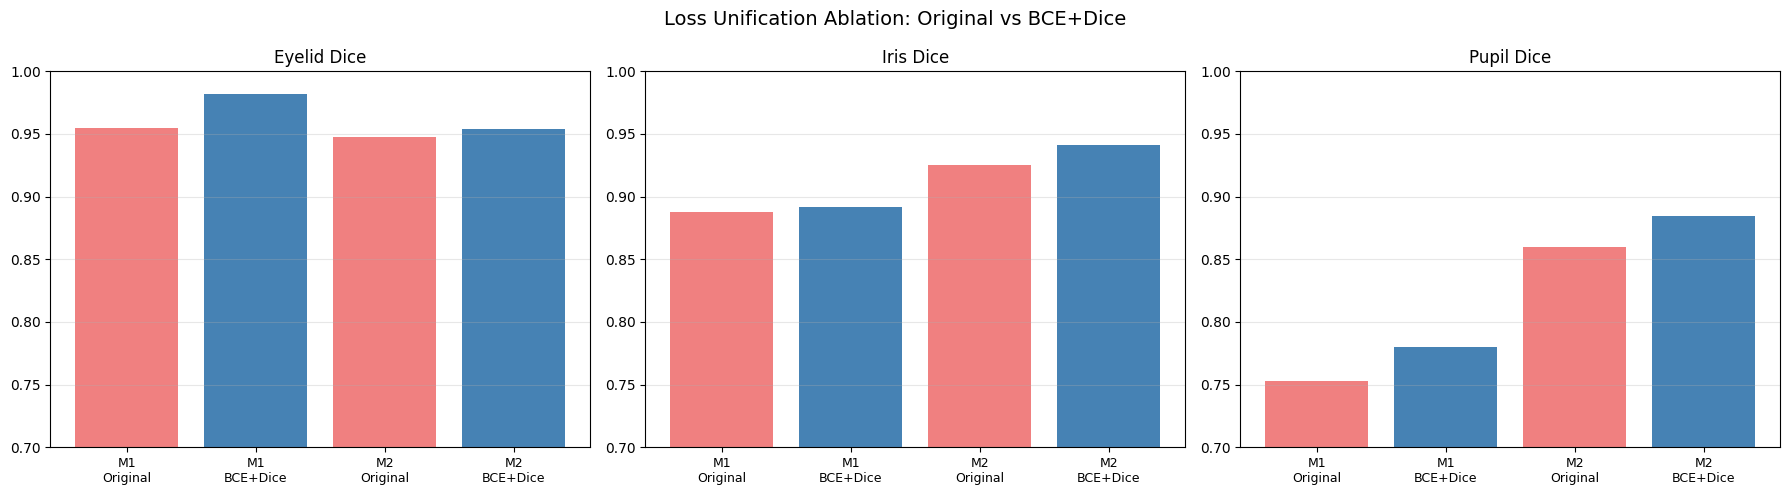

Figure saved to results\ablation_loss_unified_comparison.png


In [15]:
# ===== Visualization =====

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['dice_lid', 'dice_iris', 'dice_pupil']
titles = ['Eyelid Dice', 'Iris Dice', 'Pupil Dice']

# Original results for comparison
original = {
    1: {'dice_lid': 0.9546, 'dice_iris': 0.8874, 'dice_pupil': 0.7527},
    2: {'dice_lid': 0.9477, 'dice_iris': 0.9252, 'dice_pupil': 0.8601},
}

for ax, metric, title in zip(axes, metrics, titles):
    x_labels = []
    values = []
    colors = []

    for method_id in TRAIN_METHODS:
        # Original
        x_labels.append(f'M{method_id}\nOriginal')
        values.append(original[method_id][metric])
        colors.append('lightcoral')

        # Unified
        method_df = results_df[results_df['method'] == method_id]
        if len(method_df) > 0:
            x_labels.append(f'M{method_id}\nBCE+Dice')
            values.append(method_df[metric].mean())
            colors.append('steelblue')

    ax.bar(range(len(values)), values, color=colors)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_title(title)
    ax.set_ylim(0.7, 1.0)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Loss Unification Ablation: Original vs BCE+Dice', fontsize=14)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'ablation_loss_unified_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {RESULT_DIR / 'ablation_loss_unified_comparison.png'}")

## Discussion

### 期待される結果

1. **Method1 (BCE+Dice)**: 楕円レンダリングマスクにDiceを追加することで、
   Iris/Pupilの形状一致が改善される可能性がある。BCEは境界精度、Diceは領域重複に寄与。

2. **Method2 (Weighted BCE+Dice)**: エッジ予測にDiceを追加。
   ただしエッジは非常に薄い（3px）ため、Dice損失の効果は限定的かもしれない。

### Loss統一後の比較の意義

全メソッドがBCE(CE)+Dice系のLossで統一されることで：
- 性能差が「アーキテクチャ（出力表現の違い）」に帰属しやすくなる
- Method3(Dice only) がベースライン、Method4(CE+Dice) が参照条件として機能する